# Advanced Predictive Computer Vision: Multiclass Vehicle Classification Benchmark

This project establishes a comprehensive benchmark for multiclass vehicle image classification. Moving beyond a single-architecture approach, we model the problem evaluating the trade-offs between predictive accuracy and computational efficiency.

To process the structural complexity of the images, we have developed a comparative benchmark of six deep learning architectures (including standard CNNs, lightweight models, and Vision Transformers). The benchmark evaluates F1-Score (Macro), Accuracy, and Execution Time (Efficiency) to determine the optimal model for potential industrial deployment.

---
## 1. Importing Libraries and Environment Configuration

In [68]:
import os
import time
import copy
import warnings
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedShuffleSplit

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
import torchvision
from torchvision import datasets, transforms, models

# Suppress specific warnings to maintain a clean standard output
warnings.filterwarnings('ignore')

# Set seed for reproducibility and consistent benchmark evaluation
torch.manual_seed(42)
np.random.seed(42)

# Hardware accelerator configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Active Computation Device: {device}')

Active Computation Device: cuda


In [69]:
# Project data directory specified by the architecture parameters
DATA_DIR = r"C:\Users\arman\OneDrive\Documentos\Proyectos de programacion\Proyectos sin haberse publicado\ML-DL-SQL-MongoDB\607 Clasificación_de_imagen_Clasificacion_multiclase_PyTorch_Deep_Learning\data\Vehicles"

---
## 2. Exploratory Data Analysis (Pre-Transformation)

Before constructing the modeling pipelines, it is crucial to analyze the raw dataset. This section evaluates the class distribution to identify potential imbalances and provides a visual inspection of the raw image structures.

== Dataset Profile ==
Total samples: 5589
Detected 7 classes: ['Auto Rickshaws', 'Bikes', 'Cars', 'Motorcycles', 'Planes', 'Ships', 'Trains']



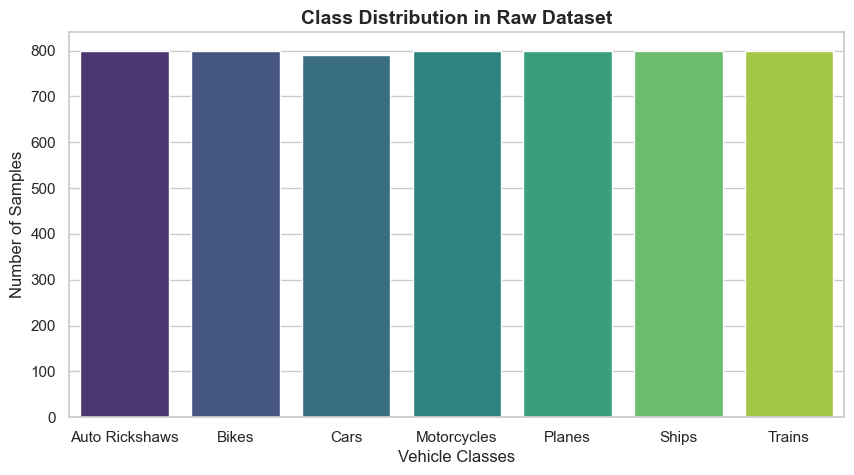

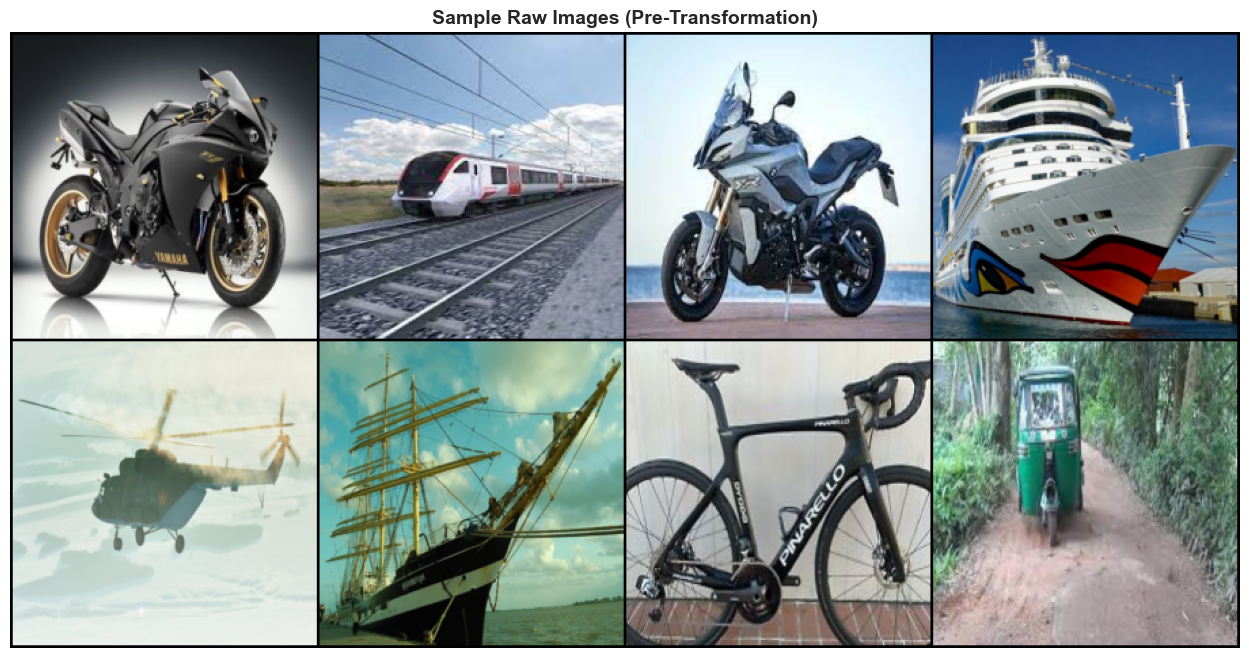

In [70]:
# Load raw dataset for exploratory analysis without complex augmentations
# We apply a simple resize strictly for unified visualization
transform_eda = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_eda = datasets.ImageFolder(root=DATA_DIR, transform=transform_eda)
class_names = dataset_eda.classes
num_classes = len(class_names)

print("== Dataset Profile ==")
print(f"Total samples: {len(dataset_eda)}")
print(f"Detected {num_classes} classes: {class_names}\n")

# CRITICAL FAILSAVE: Prevent execution if the dataset hierarchy is incorrect
assert num_classes > 1, \
    "CRITICAL ERROR: Only 1 class detected. Ensure your DATA_DIR contains subfolders for each individual class (e.g., data/car, data/truck)."

# 2.1 Plot Class Distribution
targets_eda = dataset_eda.targets
class_counts = Counter(targets_eda)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
sns.barplot(
    x=[class_names[i] for i in class_counts.keys()], 
    y=list(class_counts.values()), 
    palette="viridis"
)
plt.title("Class Distribution in Raw Dataset", fontsize=14, fontweight="bold")
plt.xlabel("Vehicle Classes")
plt.ylabel("Number of Samples")
plt.show()

# 2.2 Show a grid of raw images
loader_eda = DataLoader(dataset_eda, batch_size=8, shuffle=True)
images_eda, labels_eda = next(iter(loader_eda))

plt.figure(figsize=(16, 8))
out_eda = torchvision.utils.make_grid(images_eda, nrow=4)
# Permute dimensions from PyTorch (C, H, W) to Matplotlib (H, W, C)
plt.imshow(out_eda.permute(1, 2, 0))
plt.title("Sample Raw Images (Pre-Transformation)", fontsize=14, fontweight="bold")
plt.axis("off")
plt.show()

---
## 3. Data Processing Pipeline & Class Balancing

Defining the optimal transformations. A resolution of 224x224 is standard and mandatory for architectures like the Vision Transformer (ViT).
To handle real-world class imbalances detected during the EDA phase, we deploy a `WeightedRandomSampler` which resamples minority classes dynamically during the training epoch.

In [71]:
# Hyperparameters definition for the benchmark context
BATCH_SIZE = 32
NUM_EPOCHS = 5 # Reduced epoch count for benchmarking purposes
LEARNING_RATE = 0.001

# Image normalization metrics based on ImageNet standards
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                                 std=[0.229, 0.224, 0.225])

# Training transformations (includes Data Augmentation for generalization)
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    normalize
])

# Validation & Test transformations (Deterministic evaluation)
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    normalize
])

# Dataset instantiation mapped to structural transformations
dataset_train_base = datasets.ImageFolder(root=DATA_DIR, transform=transform_train)
dataset_val_base = datasets.ImageFolder(root=DATA_DIR, transform=transform_val)

targets = dataset_train_base.targets
NUM_CLASSES = len(class_names)

# --- 3-Way Stratified Split (Train: 70%, Val: 15%, Test: 15%) ---
# 1. Split into Train (70%) and Temp (30%)
sss_main = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(sss_main.split(np.zeros(len(targets)), targets))

# 2. Split Temp (30%) into Validation (15%) and Test (15%)
temp_targets = [targets[i] for i in temp_idx]
sss_val = StratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_rel_idx, test_rel_idx = next(sss_val.split(np.zeros(len(temp_targets)), temp_targets))

# Map relative indices back to absolute dataset indices
val_idx = [temp_idx[i] for i in val_rel_idx]
test_idx = [temp_idx[i] for i in test_rel_idx]

train_dataset = Subset(dataset_train_base, train_idx)
val_dataset = Subset(dataset_val_base, val_idx)
test_dataset = Subset(dataset_val_base, test_idx) # Uses the deterministic transform_val

# --- Class Balancing Strategy ---
train_targets = [targets[i] for i in train_idx]
class_counts_train = Counter(train_targets)

# Calculate inverse weights for each class to penalize majority classes
total_train_samples = len(train_targets)
class_weights = {cls: total_train_samples / (NUM_CLASSES * count) for cls, count in class_counts_train.items()}
sample_weights = [class_weights[t] for t in train_targets]

# Instantiate the weighted sampler
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# DataLoaders definition (Note: shuffle=False is mandatory when using a custom sampler)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Training samples allocated: {len(train_dataset)}")
print(f"Validation samples allocated: {len(val_dataset)}")
print(f"Testing samples allocated: {len(test_dataset)}")
print(f"Calculated class weighting strategy: {class_weights}")

Training samples allocated: 3912
Validation samples allocated: 838
Testing samples allocated: 839
Calculated class weighting strategy: {3: 0.9979591836734694, 5: 0.9979591836734694, 1: 0.9979591836734694, 2: 1.0105915784035133, 4: 0.9997444416049067, 6: 0.9979591836734694, 0: 0.9979591836734694}


---
## 4. Transformation Effects Analysis (Post-Transformation)

Validating the visual output of the Data Augmentation pipeline. This step confirms that crops, rotations, and color jittering are maintaining the semantic integrity of the vehicles while forcing the model to learn invariant features.

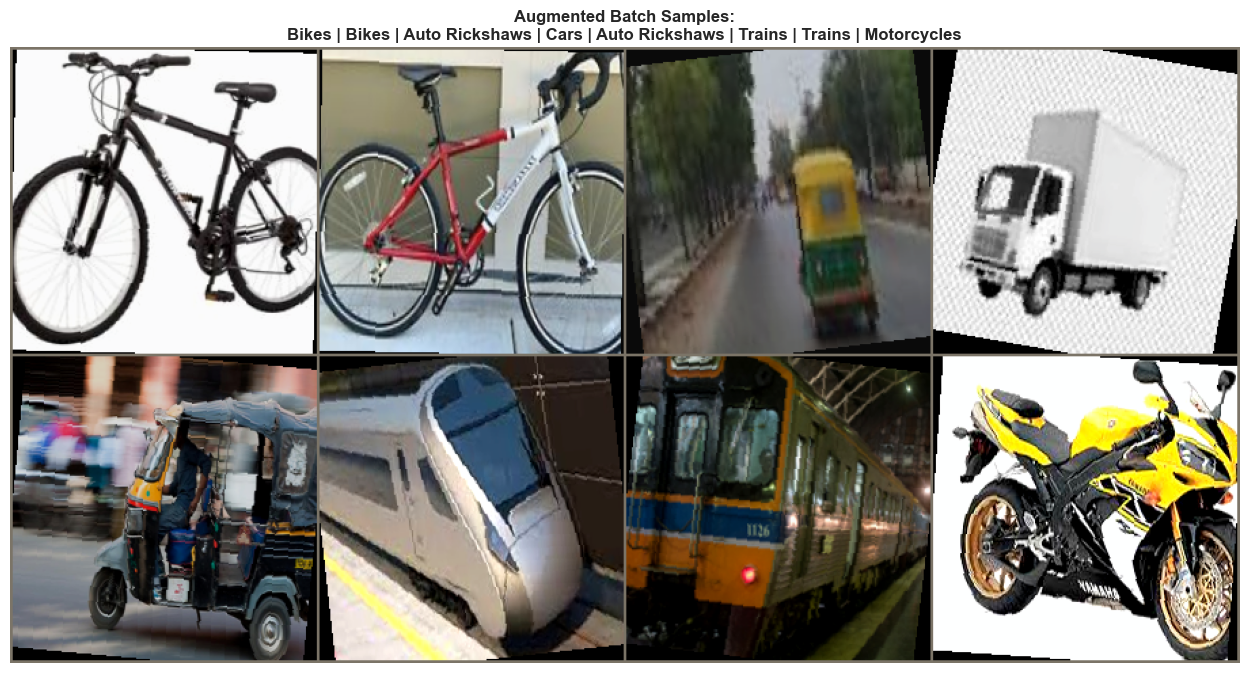

In [72]:
# Reverts the ImageNet normalization metrics strictly for Matplotlib visualization.
def unnormalize_and_show(img_tensor, labels):
    img = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    title_str = " | ".join([class_names[lbl] for lbl in labels])
    plt.title(f"Augmented Batch Samples:\n{title_str}", fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.show()

# Fetch an augmented batch from the training loader
inputs_aug, classes_aug = next(iter(train_loader))

out_aug = torchvision.utils.make_grid(inputs_aug[:8], nrow=4)
unnormalize_and_show(out_aug, classes_aug[:8].numpy())

---
## 5. Architectures Definition and Formulation

We structure a dynamic model factory function. This allows us to instantiate and modify the fully connected (classification) heads of 6 distinct architectures to map to our specific operational domain.

In [73]:
def build_model(model_name, num_classes):
    # Instantiates the requested architecture, initializes pre-trained weights, and adapts the final classification layer.
    if model_name == 'ResNet18':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'EfficientNet-B0':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'MobileNetV3-Large':
        model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        model.classifier[3] = nn.Linear(model.classifier[3].in_features, num_classes)
        
    elif model_name == 'DenseNet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    elif model_name == 'ConvNeXt-Tiny':
        model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        model.classifier[2] = nn.Linear(model.classifier[2].in_features, num_classes)
        
    elif model_name == 'ViT-B-16':
        model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
        
    else:
        raise ValueError(f"Architecture {model_name} not implemented.")
        
    return model.to(device)

---
## 6. Training and Evaluation Engine

A unified pipeline wrapper to compute standard performance metrics alongside computational temporal constraints.

In [74]:
def execute_training_pipeline(model_name, train_loader, val_loader, num_epochs=NUM_EPOCHS, patience=2):
    print(f"\n{'='*50}")
    print(f"Initializing Pipeline for Architecture: {model_name}")
    print(f"{'='*50}")
    
    model = build_model(model_name, NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    # Early stopping trackers
    best_val_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    # Start tracking computational time
    start_time = time.time()
    
    # Training phase
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            
        epoch_loss = running_loss / len(train_loader.dataset)
        
        # Validation phase calculated per epoch for Early Stopping
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                
        val_loss = val_loss / len(val_loader.dataset)
        
        # Early stopping logic evaluation
        if val_loss < best_val_loss:
            best_val_loss, epochs_no_improve = val_loss, 0
            # Create a deep copy of the weights to preserve the best version
            best_state = copy.deepcopy(model.state_dict())
            estado = "Saved"
        else:
            epochs_no_improve += 1
            estado = ""
        
        # Exact requested print format
        print(f"Epoch {epoch+1:2d} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f} {estado}")
        
        if epochs_no_improve >= patience:
            print(f"Early stopping activated during the season {epoch+1}")
            break
            
    # Compute total execution time for training
    execution_time = time.time() - start_time
    # Load the best model state to memory before returning
    model.load_state_dict(best_state)
    
    return model, execution_time


# Standardized inference function extracting predictions and probabilities.
def get_predictions(model, loader):
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            out = model(inputs)
            probs = torch.softmax(out, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
            
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

---
## 7. Sequential Execution of the Benchmark

Iterating over the defined pool of models to compile comparative data.

In [ ]:
architectures = [
    'ResNet18',
    'EfficientNet-B0',
    # Note: Additional models have been discussed to reduce training time in this benchmark phase.
    # Choosing to initially work only with ResNet18 and EfficientNet-B0 allows for pipeline validation and obtaining representative comparative metrics without compromising computational feasibility.
    #'MobileNetV3-Large',
    #'DenseNet121',
    #'ConvNeXt-Tiny',
    #'ViT-B-16'
]

benchmark_results = []
predictions_dict = {} # Dictionary to store probabilities for future ROC/AUC analysis

for model in architectures:
    # 1. Train the architecture using Train & Validation sets
    trained_model, exec_time = execute_training_pipeline(model, train_loader, val_loader)
    # 2. Extract predictions using the best saved state ON THE UNSEEN TEST SET
    y_true, y_pred, y_probs = get_predictions(trained_model, test_loader)
    # 3. Calculate external metrics
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    
    # 4. Save results
    benchmark_results.append({
        'Architecture': model,
        'Accuracy': acc,
        'F1_Score': macro_f1,
        'Execution_Time_sec': exec_time
    })
    
    predictions_dict[model] = {'y_true': y_true, 'y_pred': y_pred, 'y_probs': y_probs}
    

# Create analytical dataframe
df_results = pd.DataFrame(benchmark_results)
df_results.set_index('Architecture', inplace=True)


Initializing Pipeline for Architecture: ResNet18
Epoch  1 | Train Loss: 0.4906 | Val Loss: 0.4477 Saved
Epoch  2 | Train Loss: 0.2684 | Val Loss: 0.2682 Saved
Epoch  3 | Train Loss: 0.2773 | Val Loss: 0.3134 
Epoch  4 | Train Loss: 0.1925 | Val Loss: 0.3849 
Early stopping activated during the season 4

Initializing Pipeline for Architecture: EfficientNet-B0
Epoch  1 | Train Loss: 0.3182 | Val Loss: 0.1558 Saved
Epoch  2 | Train Loss: 0.1383 | Val Loss: 0.1210 Saved
Epoch  3 | Train Loss: 0.1051 | Val Loss: 0.0879 Saved
Epoch  4 | Train Loss: 0.1095 | Val Loss: 0.1177 
Epoch  5 | Train Loss: 0.0824 | Val Loss: 0.1687 
Early stopping activated during the season 5


---
## 8. Evaluation, Visualizations and Trade-off Analysis

Displaying the compiled performance metrics to assess both the classification capabilities and the required computational budget.

,Accuracy,F1_Score,Execution_Time_sec
Architecture,,,
EfficientNet-B0,0.974970,0.974898,518.002210
ResNet18,0.889154,0.888287,297.767077


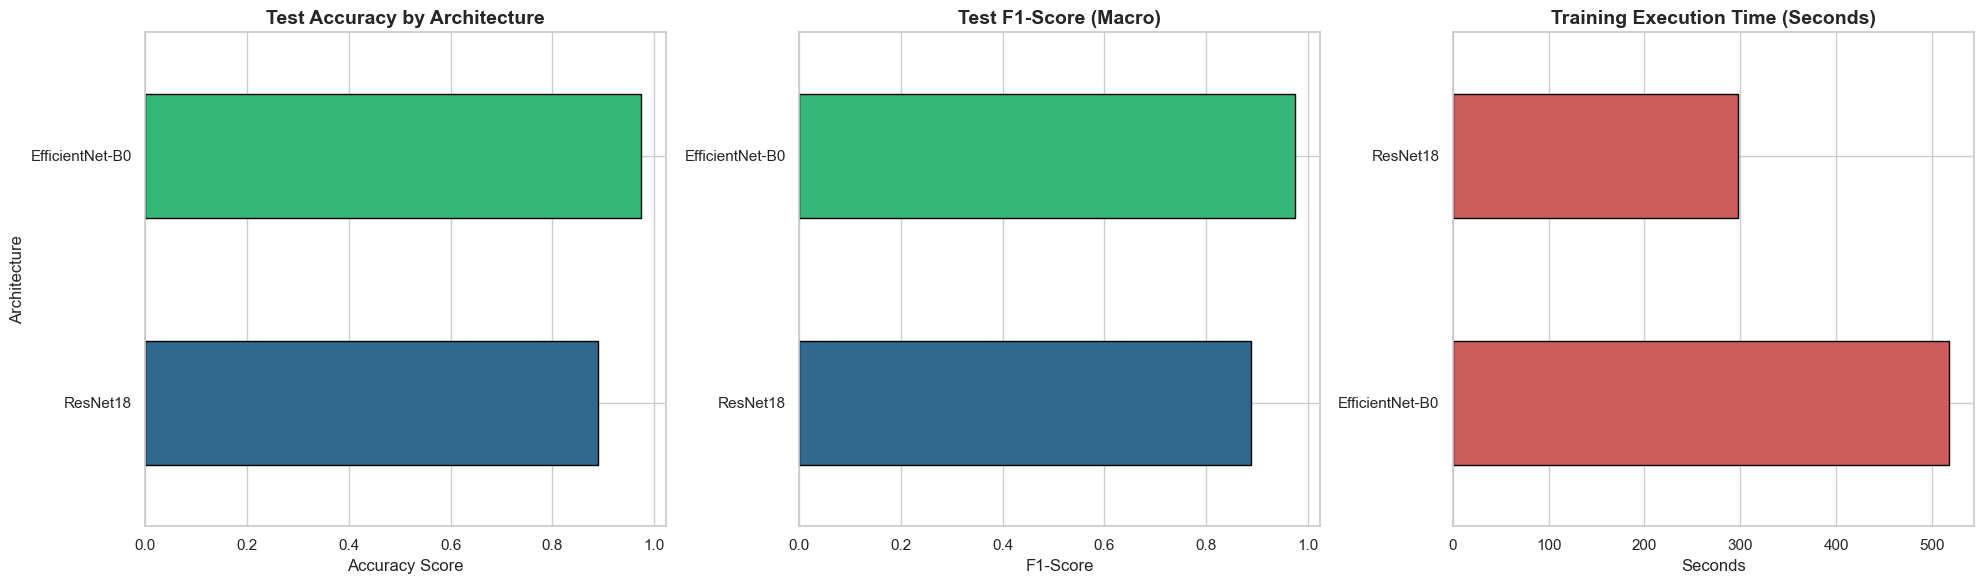


Deep-Dive Analysis for the Best Performing Architecture: EfficientNet-B0

Classification Report (Evaluated on Test Set):
                precision    recall  f1-score   support

Auto Rickshaws       0.98      0.96      0.97       120
         Bikes       0.98      1.00      0.99       120
          Cars       0.94      0.97      0.95       119
   Motorcycles       0.99      0.93      0.96       120
        Planes       0.99      0.97      0.98       120
         Ships       0.97      0.99      0.98       120
        Trains       0.98      1.00      0.99       120

      accuracy                           0.97       839
     macro avg       0.98      0.97      0.97       839
  weighted avg       0.98      0.97      0.97       839





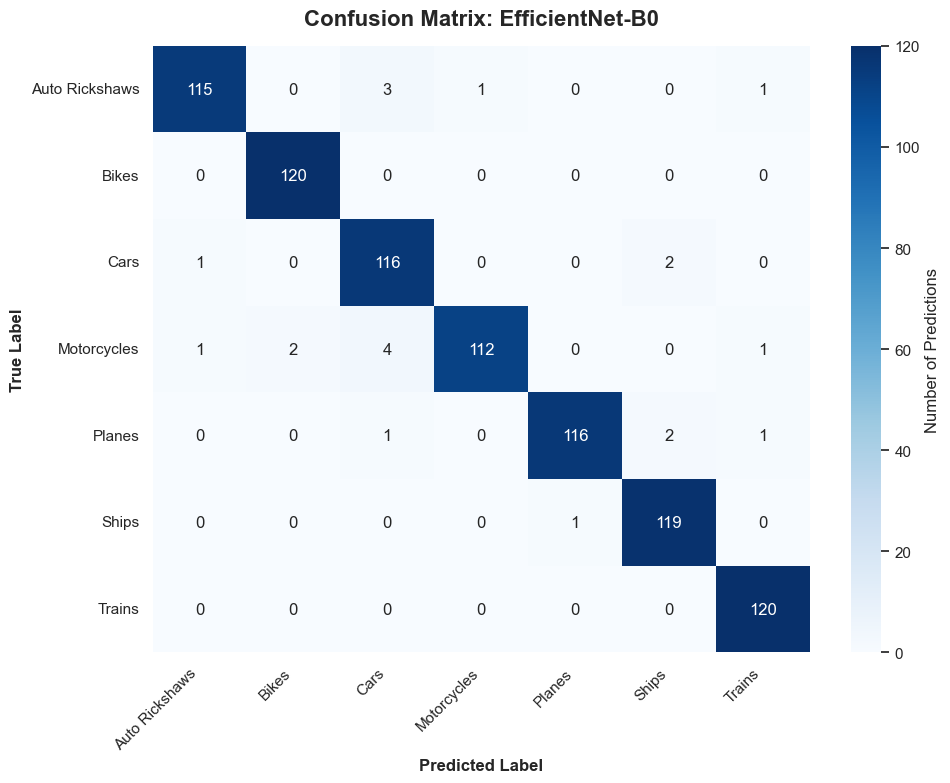

In [76]:
# ---------------------------------------------------------
# PART A: General Benchmark Overview (Accuracy, F1, Time)
# ---------------------------------------------------------
display(df_results.sort_values(by='F1_Score', ascending=False))

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
color_palette = sns.color_palette("viridis", len(architectures))

# 1. Accuracy Plot
df_results['Accuracy'].sort_values().plot(
    kind='barh', ax=axes[0], color=color_palette, edgecolor='black')
axes[0].set_title('Test Accuracy by Architecture', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Accuracy Score')
axes[0].set_ylabel('Architecture')

# 2. F1-Score Plot
df_results['F1_Score'].sort_values().plot(
    kind='barh', ax=axes[1], color=color_palette, edgecolor='black')
axes[1].set_title('Test F1-Score (Macro)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('F1-Score')
axes[1].set_ylabel('')

# 3. Execution Time Plot
df_results['Execution_Time_sec'].sort_values(ascending=False).plot(
    kind='barh', ax=axes[2], color='indianred', edgecolor='black')
axes[2].set_title('Training Execution Time (Seconds)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Seconds')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# PART B: Deep-Dive Analysis for the Best Architecture
# ---------------------------------------------------------
best_arch = df_results['F1_Score'].idxmax()
print(f"\n{'='*70}")
print(f"Deep-Dive Analysis for the Best Performing Architecture: {best_arch}")
print(f"{'='*70}\n")

y_true_best = predictions_dict[best_arch]['y_true']
y_pred_best = predictions_dict[best_arch]['y_pred']

# 1. Print Standard Classification Report
print("Classification Report (Evaluated on Test Set):")
print(classification_report(y_true_best, y_pred_best, target_names=class_names))
print("\n")

# 2. Plot Confusion Matrix
cm = confusion_matrix(y_true_best, y_pred_best)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Number of Predictions'}, annot_kws={"size": 12})

plt.title(f'Confusion Matrix: {best_arch}', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()